In [76]:
import json
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors as mcolors
from matplotlib.patches import Patch

# ============================================================================
# Global Constants & Configuration
# ============================================================================

EXCLUDED_TEST_IDS = {}  # {f"test_id_{i}" for i in range(16, 21)} | {f"test_id_{i}" for i in range(26, 31)}

QUERY_COMPLEXITY = {
    1: "high",
    2: "high",
    3: "medium",
    4: "medium",
    5: "medium",
    6: "medium",
    7: "medium",
    8: "low",
    9: "low",
    10: "low",
    11: "low",
    12: "low",
}

COMPLEXITY_BAND_COLOR = "#4a4a4a"
COMPLEXITY_BAND_ALPHA = {
    "high": 0.4,
    "medium": 0.2,
    "low": 0.07,
    "unknown": 0.04,
}

In [77]:
# ============================================================================
# Utility Functions (All Helper Functions Consolidated & Deduplicated)
# ============================================================================

def _resolve_eval_dir(target_dir: str | Path):
    """Resolve evaluation directory from workspace."""
    target_dir = Path(target_dir)
    resolved = None
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / target_dir
        if candidate.exists():
            resolved = candidate
            break

    if resolved is None:
        raise FileNotFoundError(
            f"Cannot find {target_dir}. Current working directory: {Path.cwd()}"
        )

    return resolved


def _resolve_eval_json(target_rel: str | Path):
    """Resolve and load evaluation JSON file."""
    target_rel = Path(target_rel)

    # Support both full relative paths and bare filenames.
    search_candidates = [target_rel]
    if not target_rel.is_absolute() and target_rel.parent == Path("."):
        search_candidates.extend(
            [
                Path("data/llm_eval_results_compare/comparison_llm_eval_results") / target_rel,
                Path("data/comparison_llm_eval_results") / target_rel,
            ]
        )

    resolved = None
    for base in [Path.cwd(), *Path.cwd().parents]:
        for rel in search_candidates:
            candidate = base / rel
            if candidate.exists():
                resolved = candidate
                break
        if resolved is not None:
            break

    if resolved is None:
        attempted = ", ".join(str(p) for p in search_candidates)
        raise FileNotFoundError(
            f"Cannot find any of [{attempted}]. Current working directory: {Path.cwd()}"
        )

    with resolved.open("r", encoding="utf-8") as f:
        return resolved, json.load(f)


def _group_model_sort_key(stem: str):
    """Extract group name and model name from filename stem."""
    suffix = "_llm_eval"
    core = stem[:-len(suffix)] if stem.endswith(suffix) else stem

    # Match known model suffixes at the end so group names can contain any underscores.
    known_models = ["gemini", "gpt5.4mini"]
    for model_name in known_models:
        marker = f"_{model_name}"
        if core.endswith(marker):
            group_name = core[: -len(marker)]
            return group_name, model_name

    # Fallback for unexpected names: keep deterministic ordering.
    return core, ""


def _group_name_from_stem(stem: str):
    """Extract group name from filename stem."""
    group_name, _ = _group_model_sort_key(stem)
    return group_name


def _base_group_name(group_name: str):
    """Remove _p2p suffix from group name to get base name."""
    return group_name[:-4] if group_name.endswith("_p2p") else group_name


def _filter_results_by_test_id(results: dict):
    """Filter results to exclude test IDs in EXCLUDED_TEST_IDS."""
    return {k: v for k, v in results.items() if k not in EXCLUDED_TEST_IDS}


def _blend_with_white(color, amount=0.35):
    """Blend a color with white."""
    rgb = np.array(mcolors.to_rgb(color), dtype=float)
    return tuple(rgb + (1.0 - rgb) * amount)


def _blend_with_black(color, amount=0.25):
    """Blend a color with black."""
    rgb = np.array(mcolors.to_rgb(color), dtype=float)
    return tuple(rgb * (1.0 - amount))


def _build_group_color_map(stems):
    """Build color mapping from group names to colors."""
    base_group_colors = {
        "dense_sparse": "#1F77B4",
        "llm_extract": "#FF7F0E",
        "theme_aware": "#9467BD",
    }

    group_order = []
    for stem in stems:
        group_name = _group_name_from_stem(stem)
        if group_name not in group_order:
            group_order.append(group_name)

    group_color_map = {}
    for group_name in group_order:
        base_name = _base_group_name(group_name)
        base_color = base_group_colors.get(base_name, "#4d4d4d")
        if group_name.endswith("_p2p"):
            group_color_map[group_name] = _blend_with_white(base_color, amount=0.28)
        else:
            group_color_map[group_name] = base_color

    return group_color_map


def _model_tinted_color(label: str, group_color_map):
    """Get tinted color for a model label."""
    group_name, _ = _group_model_sort_key(label)
    return group_color_map.get(group_name, "#4d4d4d")


def _extract_test_num(test_id: str):
    """Extract numeric test number from test_id."""
    return int(str(test_id).split("_")[-1])


def _query_ids_from_sorted_keys(sorted_keys, runs_per_query: int):
    """Extract query IDs from sorted test keys."""
    test_nums = [_extract_test_num(k) for k in sorted_keys]
    usable_len = (len(test_nums) // runs_per_query) * runs_per_query
    if usable_len == 0:
        return []
    grouped_nums = np.asarray(test_nums[:usable_len], dtype=int).reshape(-1, runs_per_query)
    return (((grouped_nums[:, 0] - 1) // runs_per_query) + 1).astype(int).tolist()


def _complexity_for_query_id(query_id: int):
    """Get complexity level for a query ID."""
    return QUERY_COMPLEXITY.get(int(query_id), "unknown")


def _complexity_legend_handles():
    """Create legend handles for complexity bands."""
    return [
        Patch(facecolor=COMPLEXITY_BAND_COLOR, alpha=COMPLEXITY_BAND_ALPHA["high"], edgecolor="none", label="Complexity: high"),
        Patch(facecolor=COMPLEXITY_BAND_COLOR, alpha=COMPLEXITY_BAND_ALPHA["medium"], edgecolor="none", label="Complexity: medium"),
        Patch(facecolor=COMPLEXITY_BAND_COLOR, alpha=COMPLEXITY_BAND_ALPHA["low"], edgecolor="none", label="Complexity: low"),
    ]

# Visualization Functions

In [78]:
def plot_all_files_overall_scores(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
):
    """Plot overall score distribution across all evaluation files."""
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(
        list(resolved_dir.glob(pattern)),
        key=lambda p: (*_group_model_sort_key(p.stem), p.stem),
    )

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    file_scores = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        results = data.get("results", {})
        scores = [
            record.get("overall_score", np.nan)
            for record in results.values()
            if isinstance(record, dict)
        ]
        scores = np.asarray(scores, dtype=float)
        scores = scores[~np.isnan(scores)]
        file_scores[file_path.stem] = scores

    labels = list(file_scores.keys())
    values = [file_scores[label] for label in labels]
    group_color_map = _build_group_color_map(labels)

    print(f"Loaded {len(labels)} files from: {resolved_dir}")
    for label, scores in file_scores.items():
        group_name, model_name = _group_model_sort_key(label)
        print(
            f"  [{group_name}] {model_name}: n={len(scores)}, mean={scores.mean():.3f}"
            if len(scores)
            else f"  [{group_name}] {model_name}: n=0"
        )

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
    positions = np.arange(1, len(labels) + 1)

    box = ax.boxplot(
        values,
        positions=positions,
        widths=0.5,
        showfliers=False,
        patch_artist=False,
        zorder=1,
    )
    for line in box["boxes"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["whiskers"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["caps"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["medians"]:
        line.set_color("black")
        line.set_linewidth(1.5)

    for idx, (label, scores) in enumerate(zip(labels, values), start=1):
        if len(scores) == 0:
            continue
        jitter = np.random.normal(idx, 0.08, size=len(scores))
        point_color = _model_tinted_color(label, group_color_map)
        ax.scatter(
            jitter,
            scores,
            alpha=0.7,
            s=24,
            color=point_color,
            edgecolors="none",
            zorder=3,
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=25, ha="right", color="black")
    ax.set_ylabel("overall_score", color="black")
    ax.set_title("Overall Score Distribution Across All Eval Files", color="black")
    ax.grid(True, axis="y", alpha=0.2, color="black")
    ax.tick_params(axis="both", colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()

    return file_scores


def plot_all_files_overall_scores_p2p(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
):
    """Plot overall score distribution for P2P evaluation files."""
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(
        [p for p in resolved_dir.glob(pattern) if "p2p" in p.stem.lower()],
        key=lambda p: (*_group_model_sort_key(p.stem), p.stem),
    )

    if not files:
        raise FileNotFoundError(
            f"No p2p files matching {pattern} found in {resolved_dir}"
        )

    file_scores = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        results = data.get("results", {})
        scores = [
            record.get("overall_score", np.nan)
            for record in results.values()
            if isinstance(record, dict)
        ]
        scores = np.asarray(scores, dtype=float)
        scores = scores[~np.isnan(scores)]
        file_scores[file_path.stem] = scores

    labels = list(file_scores.keys())
    values = [file_scores[label] for label in labels]
    group_color_map = _build_group_color_map(labels)

    print(f"Loaded {len(labels)} p2p files from: {resolved_dir}")
    for label, scores in file_scores.items():
        group_name, model_name = _group_model_sort_key(label)
        print(
            f"  [{group_name}] {model_name}: n={len(scores)}, mean={scores.mean():.3f}"
            if len(scores)
            else f"  [{group_name}] {model_name}: n=0"
        )

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
    positions = np.arange(1, len(labels) + 1)

    box = ax.boxplot(
        values,
        positions=positions,
        widths=0.5,
        showfliers=False,
        patch_artist=False,
        zorder=1,
    )
    for line in box["boxes"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["whiskers"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["caps"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["medians"]:
        line.set_color("black")
        line.set_linewidth(1.5)

    for idx, (label, scores) in enumerate(zip(labels, values), start=1):
        if len(scores) == 0:
            continue
        jitter = np.random.normal(idx, 0.08, size=len(scores))
        point_color = _model_tinted_color(label, group_color_map)
        ax.scatter(
            jitter,
            scores,
            alpha=0.7,
            s=24,
            color=point_color,
            edgecolors="none",
            zorder=3,
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=25, ha="right", color="black")
    ax.set_ylabel("overall_score", color="black")
    ax.set_title("P2P Overall Score Distribution", color="black")
    ax.grid(True, axis="y", alpha=0.2, color="black")
    ax.tick_params(axis="both", colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()

    return file_scores


def plot_all_files_overall_scores_models(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
    model: str = "gemini",
):
    """Plot overall score distribution for a specific model."""
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(
        [p for p in resolved_dir.glob(pattern) if model in p.stem.lower()],
        key=lambda p: (*_group_model_sort_key(p.stem), p.stem),
    )

    if not files:
        raise FileNotFoundError(
            f"No {model} files matching {pattern} found in {resolved_dir}"
        )

    file_scores = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        results = data.get("results", {})
        scores = [
            record.get("overall_score", np.nan)
            for record in results.values()
            if isinstance(record, dict)
        ]
        scores = np.asarray(scores, dtype=float)
        scores = scores[~np.isnan(scores)]
        file_scores[file_path.stem] = scores

    labels = list(file_scores.keys())
    values = [file_scores[label] for label in labels]
    group_color_map = _build_group_color_map(labels)

    print(f"Loaded {len(labels)} {model} files from: {resolved_dir}")
    for label, scores in file_scores.items():
        group_name, model_name = _group_model_sort_key(label)
        print(
            f"  [{group_name}] {model_name}: n={len(scores)}, mean={scores.mean():.3f}"
            if len(scores)
            else f"  [{group_name}] {model_name}: n=0"
        )

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
    positions = np.arange(1, len(labels) + 1)

    box = ax.boxplot(
        values,
        positions=positions,
        widths=0.5,
        showfliers=False,
        patch_artist=False,
        zorder=1,
    )
    for line in box["boxes"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["whiskers"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["caps"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["medians"]:
        line.set_color("black")
        line.set_linewidth(1.5)

    for idx, (label, scores) in enumerate(zip(labels, values), start=1):
        if len(scores) == 0:
            continue
        jitter = np.random.normal(idx, 0.08, size=len(scores))
        point_color = _model_tinted_color(label, group_color_map)
        ax.scatter(
            jitter,
            scores,
            alpha=0.7,
            s=24,
            color=point_color,
            edgecolors="none",
            zorder=3,
        )

    ax.set_xticks(positions)
    display_labels = [label.replace("_gemini_llm_eval", "").replace("_gpt_llm_eval", "").replace("_llm_eval", "") for label in labels]
    ax.set_xticklabels(display_labels, rotation=25, ha="center", color="black")
    ax.set_ylabel("overall_score", color="black")
    ax.set_title(f"{model.capitalize()} Overall Score Distribution", color="black")
    ax.grid(True, axis="y", alpha=0.2, color="black")
    ax.tick_params(axis="both", colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()

    return file_scores


def plot_overall_scores_by_query(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
    runs_per_query: int = 5,
):
    """Plot overall scores grouped by query with complexity bands."""
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(
        list(resolved_dir.glob(pattern)),
        key=lambda p: (*_group_model_sort_key(p.stem), p.stem),
    )

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    file_names = []
    file_series = []
    file_query_ids = []
    query_count = None

    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        filtered_results = _filter_results_by_test_id(data.get("results", {}))
        sorted_keys = sorted(filtered_results.keys(), key=lambda x: int(x.split("_")[-1]))
        query_ids = _query_ids_from_sorted_keys(sorted_keys, runs_per_query)
        scores = np.array(
            [filtered_results[k].get("overall_score", np.nan) for k in sorted_keys],
            dtype=float,
        )
        scores = scores[~np.isnan(scores)]
        usable = scores[: (len(scores) // runs_per_query) * runs_per_query]
        if usable.size == 0:
            continue

        grouped = usable.reshape(-1, runs_per_query)
        query_means = grouped.mean(axis=1)

        if query_count is None:
            query_count = len(query_means)
        else:
            query_count = min(query_count, len(query_means))

        file_names.append(file_path.stem)
        file_series.append(query_means)
        file_query_ids.append(query_ids)

    if query_count is None or query_count == 0:
        raise ValueError("No overall_score values found in the selected files")

    query_count = int(query_count)
    file_series = [means[:query_count] for means in file_series]
    shared_query_ids = file_query_ids[0][:query_count] if file_query_ids else list(range(1, query_count + 1))
    query_labels = [f"Q{qid}" for qid in shared_query_ids]
    group_color_map = _build_group_color_map(file_names)

    print(f"Loaded {len(file_series)} files from: {resolved_dir}")
    print(f"Excluded test IDs: {sorted(EXCLUDED_TEST_IDS)}")
    print(f"Queries per file: {query_count}")
    print(f"Runs per query: {runs_per_query}")
    print("Complexity by query:")
    for qid in shared_query_ids:
        print(f"  Q{qid}: {_complexity_for_query_id(qid)}")

    fig, ax = plt.subplots(figsize=(max(14, query_count * 1.1), 6.5))
    x = np.arange(query_count)
    n_files = len(file_names)
    group_width = 0.8
    bar_width = group_width / max(n_files, 1)
    offsets = (np.arange(n_files) - (n_files - 1) / 2) * bar_width

    for i, qid in enumerate(shared_query_ids):
        complexity = _complexity_for_query_id(qid)
        band_alpha = COMPLEXITY_BAND_ALPHA.get(complexity, COMPLEXITY_BAND_ALPHA["unknown"])
        ax.axvspan(i - 0.5, i + 0.5, color=COMPLEXITY_BAND_COLOR, alpha=band_alpha, zorder=0)

    for file_idx, (file_name, means) in enumerate(zip(file_names, file_series)):
        positions = x + offsets[file_idx]
        bar_color = _model_tinted_color(file_name, group_color_map)
        ax.bar(
            positions,
            means,
            width=bar_width * 0.95,
            alpha=0.9,
            color=bar_color,
            label=file_name,
            zorder=2,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(query_labels)
    ax.set_xlabel("Query ID")
    ax.set_ylabel("overall_score")
    ax.set_title("Overall Score by Query Across All Eval Files")
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y", alpha=0.2)

    file_handles, file_labels = ax.get_legend_handles_labels()
    label_to_handle = {label: handle for handle, label in zip(file_handles, file_labels)}

    group_to_models = {}
    for label in file_labels:
        group_name, model_name = _group_model_sort_key(label)
        group_to_models.setdefault(group_name, {})[model_name] = label

    group_order = []
    for label in file_labels:
        group_name, _ = _group_model_sort_key(label)
        if group_name not in group_order:
            group_order.append(group_name)

    model_order = ["gemini", "gpt5.4mini"]
    paired_model_labels = []
    for group_name in group_order:
        for model in model_order:
            label = group_to_models.get(group_name, {}).get(model)
            if label:
                paired_model_labels.append(label)
    paired_model_handles = [label_to_handle[label] for label in paired_model_labels]

    complexity_handles = _complexity_legend_handles()
    complexity_labels = [h.get_label() for h in complexity_handles]

    model_legend = fig.legend(
        paired_model_handles,
        paired_model_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.08),
        ncol=max(len(group_order), 1),
        frameon=True,
        title="Models by Group (gemini/gpt)",
    )
    fig.add_artist(model_legend)

    fig.legend(
        complexity_handles,
        complexity_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.03),
        ncol=3,
        frameon=True,
        title="Complexity",
    )

    plt.tight_layout(rect=(0, 0.07, 1, 1))
    plt.show()

    return file_names, file_series


def compare_models_by_question_scatter(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
    runs_per_query: int = 5,
    include_p2p: bool = True,
    groups: list[str] | None = None,
):
    """Create scatter plot comparing model performance question-by-question."""
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(
        list(resolved_dir.glob(pattern)),
        key=lambda p: (*_group_model_sort_key(p.stem), p.stem),
    )

    if not include_p2p:
        files = [p for p in files if "p2p" not in p.stem.lower()]

    if groups:
        selected = {g.lower() for g in groups}
        files = [
            p
            for p in files
            if _group_model_sort_key(p.stem)[0].lower() in selected
        ]

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    paired_models = {}
    for file_path in files:
        group_name, model_name = _group_model_sort_key(file_path.stem)
        model_name = model_name.lower()
        if model_name == "gpt5.4mini":
            model_name = "gpt"
        if model_name not in {"gemini", "gpt"}:
            continue
        paired_models.setdefault(group_name, {})[model_name] = file_path

    paired_groups = {
        group: model_map
        for group, model_map in paired_models.items()
        if "gemini" in model_map and "gpt" in model_map
    }

    if not paired_groups:
        raise ValueError(
            "No paired gemini/gpt files found. Check file naming and pattern filters."
        )

    rows = []
    for group_name, model_map in paired_groups.items():
        model_scores = {}
        model_query_ids = {}

        for model_name, file_path in model_map.items():
            with file_path.open("r", encoding="utf-8") as f:
                data = json.load(f)

            filtered_results = _filter_results_by_test_id(data.get("results", {}))
            sorted_keys = sorted(
                filtered_results.keys(),
                key=lambda x: int(str(x).split("_")[-1]),
            )

            query_ids = _query_ids_from_sorted_keys(sorted_keys, runs_per_query)
            scores = np.array(
                [filtered_results[k].get("overall_score", np.nan) for k in sorted_keys],
                dtype=float,
            )
            usable = scores[: (len(scores) // runs_per_query) * runs_per_query]
            if usable.size == 0:
                continue

            grouped = usable.reshape(-1, runs_per_query)
            model_scores[model_name] = grouped.mean(axis=1)
            model_query_ids[model_name] = query_ids[: grouped.shape[0]]

        if "gemini" not in model_scores or "gpt" not in model_scores:
            continue

        qcount = min(len(model_scores["gemini"]), len(model_scores["gpt"]))
        if qcount == 0:
            continue

        gem_means = model_scores["gemini"][:qcount]
        gpt_means = model_scores["gpt"][:qcount]
        qids = model_query_ids["gemini"][:qcount]

        for idx in range(qcount):
            rows.append(
                {
                    "group": group_name,
                    "query_id": int(qids[idx]),
                    "gemini_mean": float(gem_means[idx]),
                    "gpt_mean": float(gpt_means[idx]),
                    "delta_gpt_minus_gemini": float(gpt_means[idx] - gem_means[idx]),
                }
            )

    if not rows:
        raise ValueError("Paired groups found, but no aligned query-level scores to plot.")

    model_marker_map = {
        "dense_sparse": "o",
        "llm_extract": "s",
        "theme_aware": "^",
    }

    query_ids = sorted({r["query_id"] for r in rows})
    question_palette = [
        "#D81B60", "#1E88E5", "#FFC107", "#004D40", "#E64A19",
        "#6A1B9A", "#00897B", "#C2185B", "#7CB342", "#5D4037",
        "#3949AB", "#F4511E",
    ]
    question_color_map = {
        qid: question_palette[i % len(question_palette)]
        for i, qid in enumerate(query_ids)
    }

    all_means = [r["gemini_mean"] for r in rows] + [r["gpt_mean"] for r in rows]
    lower = max(0.0, min(all_means) - 0.03)
    upper = min(1.0, max(all_means) + 0.03)

    fig, ax = plt.subplots(figsize=(9, 8))
    for r in rows:
        model_name = _base_group_name(r["group"])
        marker = model_marker_map.get(model_name, "D")
        color = question_color_map[r["query_id"]]
        ax.scatter(
            r["gemini_mean"],
            r["gpt_mean"],
            marker=marker,
            color=color,
            alpha=0.92,
            s=62,
            edgecolors="none",
        )

    # Add diagonal dotted line to show y=x (equal performance)
    ax.plot([lower, upper], [lower, upper], 'k--', alpha=0.35, linewidth=1.2, label="y=x (equal)")

    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.set_xlabel("Gemini per-question mean overall_score")
    ax.set_ylabel("GPT per-question mean overall_score")
    ax.set_title("Question-level Model Comparison (mean only)")
    ax.grid(True, alpha=0.2)

    wins_gpt = sum(1 for r in rows if r["delta_gpt_minus_gemini"] > 1e-9)
    wins_gemini = sum(1 for r in rows if r["delta_gpt_minus_gemini"] < -1e-9)
    ties = len(rows) - wins_gpt - wins_gemini
    text = f"GPT wins: {wins_gpt} | Gemini wins: {wins_gemini} | Ties: {ties}"
    ax.text(
        0.98,
        0.97,
        text,
        transform=ax.transAxes,
        va="top",
        ha="right",
        fontsize=10,
        bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "none", "pad": 3},
    )

    model_handles = [
        plt.Line2D([0], [0], marker=mk, color="black", linestyle="", markersize=7, label=name)
        for name, mk in [("dense_sparse", "o"), ("llm_extract", "s"), ("theme_aware", "^")]
    ]
    question_handles = [
        plt.Line2D([0], [0], marker="o", color=question_color_map[qid], linestyle="", markersize=6, label=f"Q{qid}")
        for qid in query_ids
    ]

    legend1 = ax.legend(handles=model_handles, loc="upper left", title="Model (shape)")
    ax.add_artist(legend1)
    ax.legend(
        handles=question_handles,
        loc="lower right",
        title="Question (color)",
        ncol=2,
        fontsize=9,
    )

    plt.tight_layout()
    plt.show()

    sorted_rows = sorted(rows, key=lambda r: (r["group"], r["query_id"]))
    for r in sorted_rows:
        winner = "gpt" if r["delta_gpt_minus_gemini"] > 1e-9 else (
            "gemini" if r["delta_gpt_minus_gemini"] < -1e-9 else "tie"
        )
        print(
            f"[{r['group']}] Q{r['query_id']:02d}: "
            f"gemini={r['gemini_mean']:.3f}, gpt={r['gpt_mean']:.3f}, "
            f"delta={r['delta_gpt_minus_gemini']:+.3f} -> {winner}"
        )

    return rows


def plot_eval_results(
    target_rel: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results/self_generated_test_cases_eval.json",
    runs_per_query: int = 5,
):
    """Plot evaluation metrics with stability analysis."""
    resolved, data = _resolve_eval_json(target_rel)

    results = _filter_results_by_test_id(data["results"])
    sorted_keys = sorted(results.keys(), key=lambda x: int(x.split("_")[-1]))

    metric_series = {
        "policy_faithfulness": np.array(
            [results[k].get("policy", {}).get("faithfulness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "policy_answer_relevance": np.array(
            [results[k].get("policy", {}).get("answer_relevance", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "policy_correctness": np.array(
            [results[k].get("policy", {}).get("correctness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "provider_faithfulness": np.array(
            [results[k].get("provider", {}).get("faithfulness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "provider_answer_relevance": np.array(
            [results[k].get("provider", {}).get("answer_relevance", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "provider_correctness": np.array(
            [results[k].get("provider", {}).get("correctness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "query_alignment": np.array(
            [results[k].get("query_alignment", {}).get("comparison_query_relevance", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "correctness": np.array(
            [results[k].get("compare_quality", {}).get("correctness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "accuracy_sim": np.array(
            [results[k].get("compare_quality", {}).get("accuracy_sim", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "accuracy_diff": np.array(
            [results[k].get("compare_quality", {}).get("accuracy_diff", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "completeness": np.array(
            [results[k].get("compare_quality", {}).get("completeness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "balance": np.array(
            [results[k].get("compare_quality", {}).get("balance", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "comparison_overall_score": np.array(
            [results[k].get("comparison_overall_score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "overall_score": np.array(
            [results[k].get("overall_score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
    }

    plot_metrics = [
        "policy_faithfulness",
        "policy_answer_relevance",
        "policy_correctness",
        "provider_faithfulness",
        "provider_answer_relevance",
        "provider_correctness",
        "query_alignment",
        "correctness",
        "accuracy_sim",
        "accuracy_diff",
        "completeness",
        "balance",
        "comparison_overall_score",
        "overall_score",
    ]

    print(f"Loaded from: {resolved}")
    print(f"Excluded test IDs: {sorted(EXCLUDED_TEST_IDS)}")
    print(f"Total cases after filter: {len(sorted_keys)}")
    print(f"Runs per query: {runs_per_query}")

    fig, axes = plt.subplots(len(plot_metrics), 1, figsize=(9, 4 * len(plot_metrics)), sharex=False)
    if len(plot_metrics) == 1:
        axes = [axes]

    for ax, metric_name in zip(axes, plot_metrics):
        values = np.asarray(metric_series[metric_name], dtype=float)
        usable = values[: (len(values) // runs_per_query) * runs_per_query]
        grouped = usable.reshape(-1, runs_per_query)

        means = grouped.mean(axis=1)
        stds = grouped.std(axis=1)
        x = np.arange(len(means))

        ax.errorbar(x, means, yerr=stds, fmt='o', capsize=5, color='black', label='Mean ± Std', zorder=3)

        for i in range(grouped.shape[0]):
            jitter = np.random.normal(i, 0.05, size=grouped.shape[1])
            if i == 0:
                ax.scatter(jitter, grouped[i], alpha=0.6, label='Individual Runs', zorder=2)
            else:
                ax.scatter(jitter, grouped[i], alpha=0.6, zorder=2)

        ax.set_xlabel("Query ID")
        ax.set_ylabel("Score")
        ax.set_title(f"{metric_name} Stability and Distribution Across {runs_per_query} Runs")
        ax.set_xticks(x)
        ax.set_xticklabels([f"Q{i+1}" for i in range(len(means))])
        ax.legend()
        ax.grid(True, axis='y', alpha=0.2)

    plt.tight_layout()
    plt.show()
    return resolved, metric_series


def export_flat_scores(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
):
    """Export evaluation scores to flat CSV format."""
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted([p for p in resolved_dir.glob(pattern) if "p2p" not in p.stem.lower()])

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    exported = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        filtered_results = _filter_results_by_test_id(data["results"])
        sorted_keys = sorted(filtered_results.keys(), key=lambda x: int(x.split("_")[-1]))

        rows = []
        for test_id in sorted_keys:
            record = filtered_results[test_id]
            policy = record.get("policy", {})
            provider = record.get("provider", {})
            query_alignment = record.get("query_alignment", {})
            compare_quality = record.get("compare_quality", {})

            row = {
                "test_id": test_id,
                "query": record.get("query", ""),
                "answer": record.get("answer", ""),
                "policy_faithfulness": policy.get("faithfulness", {}).get("score", ""),
                "policy_answer_relevance": policy.get("answer_relevance", {}).get("score", ""),
                "policy_correctness": policy.get("correctness", {}).get("score", ""),
                "provider_faithfulness": provider.get("faithfulness", {}).get("score", ""),
                "provider_answer_relevance": provider.get("answer_relevance", {}).get("score", ""),
                "provider_correctness": provider.get("correctness", {}).get("score", ""),
                "query_alignment": query_alignment.get("comparison_query_relevance", ""),
                "correctness": compare_quality.get("correctness", {}).get("score", ""),
                "accuracy_sim": compare_quality.get("accuracy_sim", {}).get("score", ""),
                "accuracy_diff": compare_quality.get("accuracy_diff", {}).get("score", ""),
                "completeness": compare_quality.get("completeness", {}).get("score", ""),
                "balance": compare_quality.get("balance", {}).get("score", ""),
                "comparison_overall_score": record.get("comparison_overall_score", ""),
                "overall_score": record.get("overall_score", ""),
            }
            rows.append(row)

        csv_path = file_path.with_name(file_path.stem + "_flat_scores.csv")
        fieldnames = list(rows[0].keys()) if rows else []

        with csv_path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(rows)

        exported[file_path.name] = csv_path
        print(f"Loaded from: {file_path}")
        print(f"Excluded test IDs: {sorted(EXCLUDED_TEST_IDS)}")
        print(f"Wrote CSV to: {csv_path}")
        print(f"Rows written: {len(rows)}")

    return exported

# Aggregated Visualization

## All Files

### Zoomed Graph

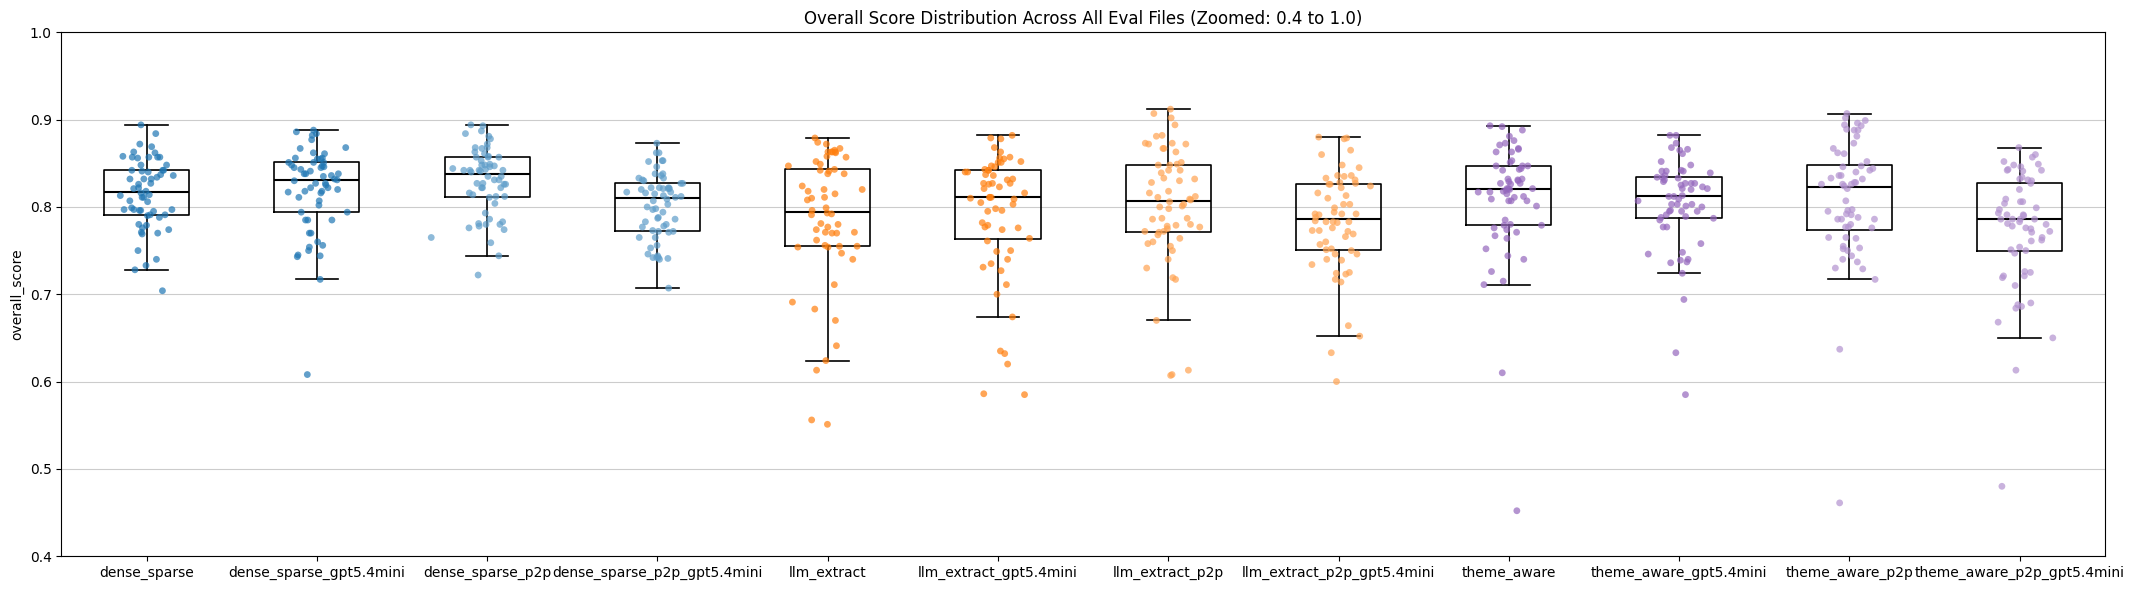

In [79]:
# Zoom-in view for all-files overall score distribution (y-axis: 0.4 to 1.0)
if "file_scores" not in globals() or not file_scores:
    file_scores = plot_all_files_overall_scores()

labels = list(file_scores.keys())
values = [file_scores[label] for label in labels]
group_color_map = _build_group_color_map(labels)

fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
positions = np.arange(1, len(labels) + 1)

box = ax.boxplot(
    values,
    positions=positions,
    widths=0.5,
    showfliers=False,
    patch_artist=False,
    zorder=1,
)
for line in box["boxes"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["whiskers"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["caps"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["medians"]:
    line.set_color("black")
    line.set_linewidth(1.5)

for idx, (label, scores) in enumerate(zip(labels, values), start=1):
    if len(scores) == 0:
        continue
    jitter = np.random.normal(idx, 0.08, size=len(scores))
    point_color = _model_tinted_color(label, group_color_map)
    ax.scatter(
        jitter,
        scores,
        alpha=0.7,
        s=24,
        color=point_color,
        edgecolors="none",
        zorder=3,
    )

ax.set_xticks(positions)
display_labels = [label.replace("_gemini_llm_eval", "").replace("_gpt_llm_eval", "").replace("_llm_eval", "") for label in labels]
ax.set_xticklabels(display_labels, ha="center", color="black")
ax.set_ylabel("overall_score", color="black")
ax.set_title("Overall Score Distribution Across All Eval Files (Zoomed: 0.4 to 1.0)", color="black")
ax.set_ylim(0.4, 1.0)
ax.grid(True, axis="y", alpha=0.2, color="black")
ax.tick_params(axis="both", colors="black")
for spine in ax.spines.values():
    spine.set_color("black")
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()
plt.show()

## Visualization w/o P2P

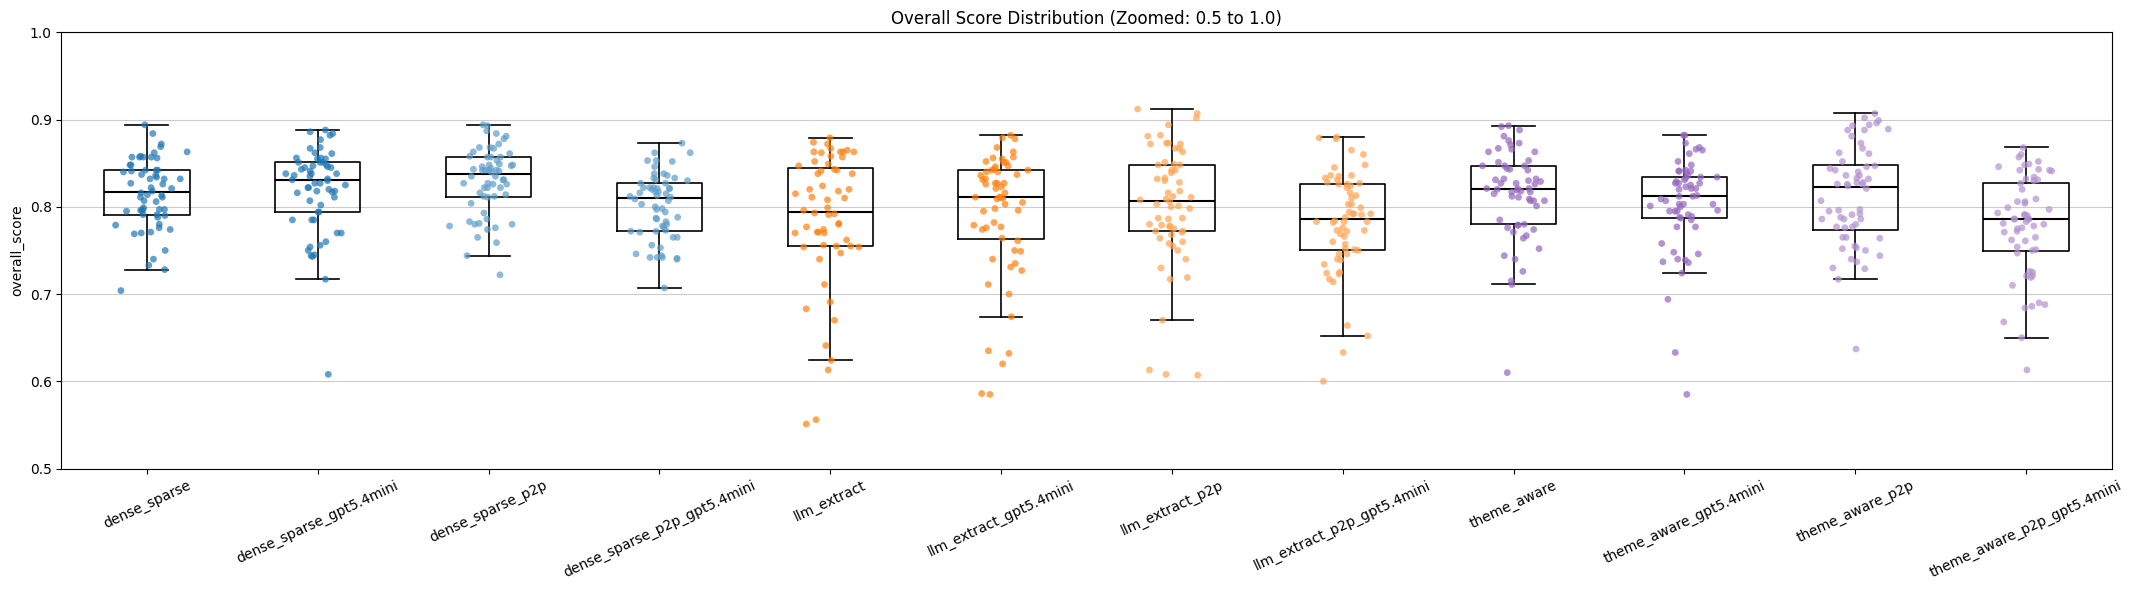

In [80]:
# Zoom-in view for overall score distribution (y-axis: 0.5 to 1.0)
if "file_scores" not in globals() or not file_scores:
    file_scores = plot_all_files_overall_scores()

labels = list(file_scores.keys())
values = [file_scores[label] for label in labels]
group_color_map = _build_group_color_map(labels)

fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
positions = np.arange(1, len(labels) + 1)

box = ax.boxplot(
    values,
    positions=positions,
    widths=0.5,
    showfliers=False,
    patch_artist=False,
    zorder=1,
)
for line in box["boxes"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["whiskers"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["caps"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["medians"]:
    line.set_color("black")
    line.set_linewidth(1.5)

for idx, (label, scores) in enumerate(zip(labels, values), start=1):
    if len(scores) == 0:
        continue
    jitter = np.random.normal(idx, 0.08, size=len(scores))
    point_color = _model_tinted_color(label, group_color_map)
    ax.scatter(
        jitter,
        scores,
        alpha=0.7,
        s=24,
        color=point_color,
        edgecolors="none",
        zorder=3,
    )

ax.set_xticks(positions)
display_labels = [label.replace("_gemini_llm_eval", "").replace("_gpt_llm_eval", "").replace("_llm_eval", "") for label in labels]
ax.set_xticklabels(display_labels, rotation=25, ha="center", color="black")
ax.set_ylabel("overall_score", color="black")
ax.set_title("Overall Score Distribution (Zoomed: 0.5 to 1.0)", color="black")
ax.set_ylim(0.5, 1.0)
ax.grid(True, axis="y", alpha=0.2, color="black")
ax.tick_params(axis="both", colors="black")
for spine in ax.spines.values():
    spine.set_color("black")
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()
plt.show()

## Visualization with P2P

Loaded 6 p2p files from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results
  [dense_sparse_p2p] gemini: n=60, mean=0.829
  [dense_sparse_p2p] gpt5.4mini: n=60, mean=0.801
  [llm_extract_p2p] gemini: n=60, mean=0.802
  [llm_extract_p2p] gpt5.4mini: n=60, mean=0.782
  [theme_aware_p2p] gemini: n=60, mean=0.807
  [theme_aware_p2p] gpt5.4mini: n=60, mean=0.774


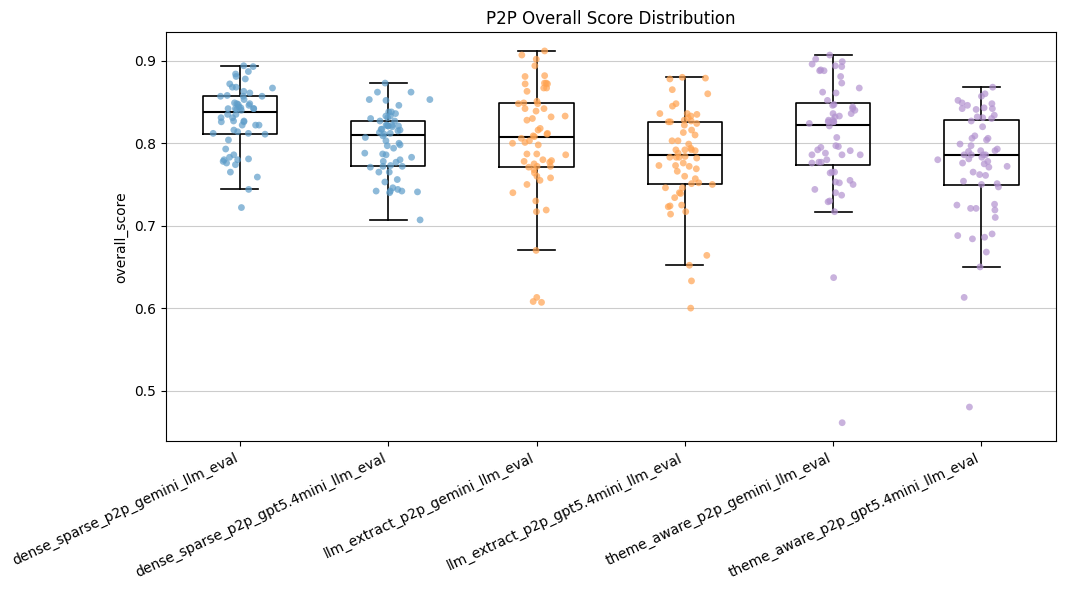

In [81]:
def plot_all_files_overall_scores_p2p(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(
        [p for p in resolved_dir.glob(pattern) if "p2p" in p.stem.lower()],
        key=lambda p: (*_group_model_sort_key(p.stem), p.stem),
    )

    if not files:
        raise FileNotFoundError(
            f"No p2p files matching {pattern} found in {resolved_dir}"
        )

    file_scores = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        results = data.get("results", {})
        scores = [
            record.get("overall_score", np.nan)
            for record in results.values()
            if isinstance(record, dict)
        ]
        scores = np.asarray(scores, dtype=float)
        scores = scores[~np.isnan(scores)]
        file_scores[file_path.stem] = scores

    labels = list(file_scores.keys())
    values = [file_scores[label] for label in labels]
    group_color_map = _build_group_color_map(labels)

    print(f"Loaded {len(labels)} p2p files from: {resolved_dir}")
    for label, scores in file_scores.items():
        group_name, model_name = _group_model_sort_key(label)
        print(
            f"  [{group_name}] {model_name}: n={len(scores)}, mean={scores.mean():.3f}"
            if len(scores)
            else f"  [{group_name}] {model_name}: n=0"
        )

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
    positions = np.arange(1, len(labels) + 1)

    box = ax.boxplot(
        values,
        positions=positions,
        widths=0.5,
        showfliers=False,
        patch_artist=False,
        zorder=1,
    )
    for line in box["boxes"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["whiskers"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["caps"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["medians"]:
        line.set_color("black")
        line.set_linewidth(1.5)

    for idx, (label, scores) in enumerate(zip(labels, values), start=1):
        if len(scores) == 0:
            continue
        jitter = np.random.normal(idx, 0.08, size=len(scores))
        point_color = _model_tinted_color(label, group_color_map)
        ax.scatter(
            jitter,
            scores,
            alpha=0.7,
            s=24,
            color=point_color,
            edgecolors="none",
            zorder=3,
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=25, ha="right", color="black")
    ax.set_ylabel("overall_score", color="black")
    ax.set_title("P2P Overall Score Distribution", color="black")
    ax.grid(True, axis="y", alpha=0.2, color="black")
    ax.tick_params(axis="both", colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()

    return file_scores


p2p_file_scores = plot_all_files_overall_scores_p2p()

## Visualization (Gemini)

Loaded 6 gemini files from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results
  [dense_sparse] gemini: n=60, mean=0.815
  [dense_sparse_p2p] gemini: n=60, mean=0.829
  [llm_extract] gemini: n=60, mean=0.760
  [llm_extract_p2p] gemini: n=60, mean=0.802
  [theme_aware] gemini: n=60, mean=0.808
  [theme_aware_p2p] gemini: n=60, mean=0.807


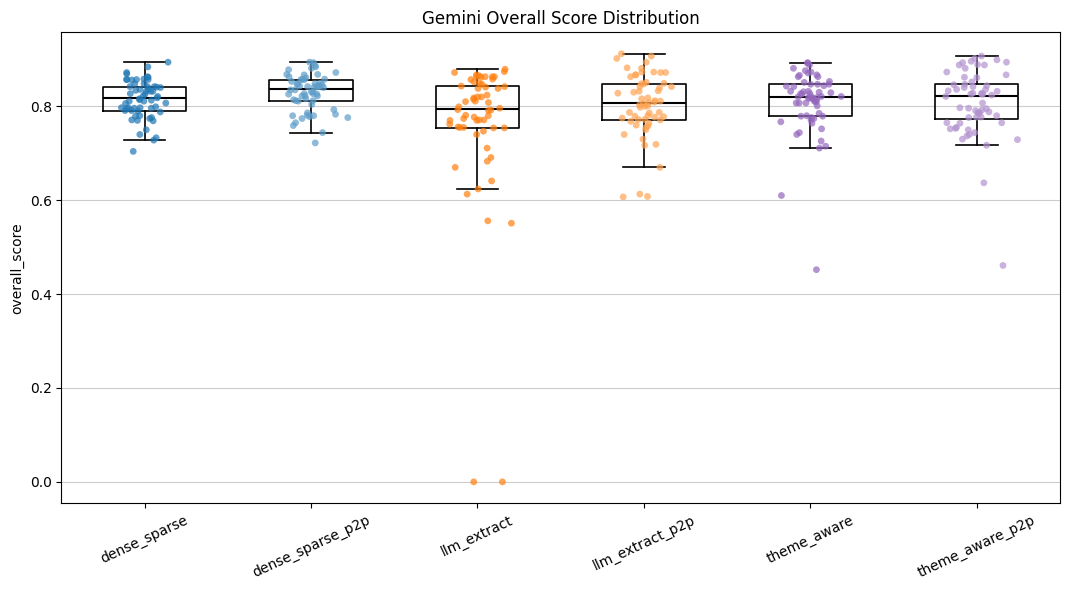

In [82]:
gemini_file_scores = plot_all_files_overall_scores_models(model="gemini")

### Zoomed Graph

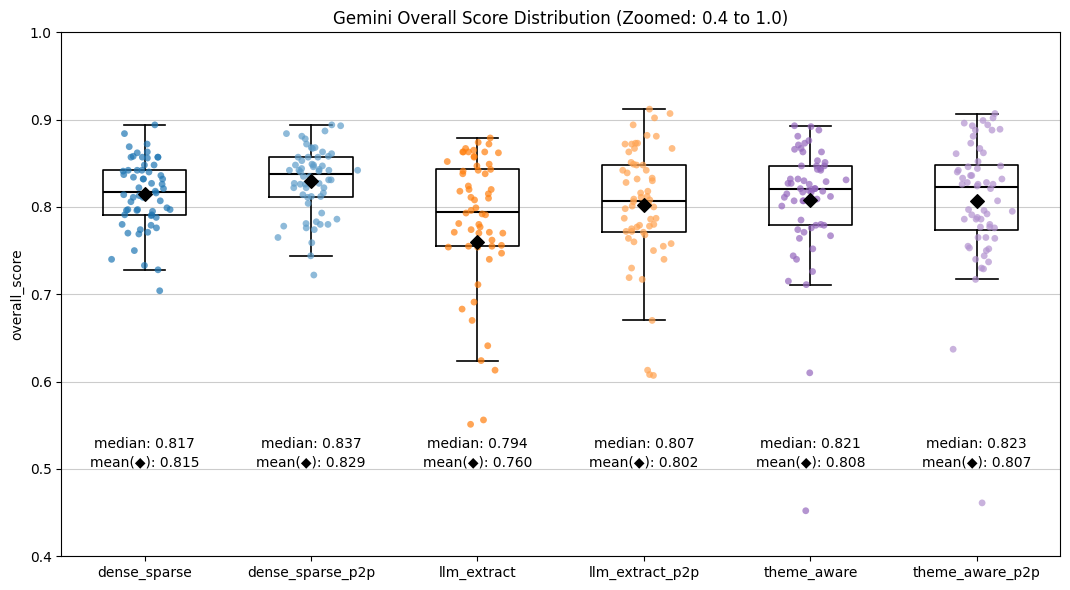

In [83]:
# Zoom-in view for Gemini overall score distribution (y-axis: 0.4 to 1.0)
if "gemini_file_scores" not in globals() or not gemini_file_scores:
    gemini_file_scores = plot_all_files_overall_scores_models(model="gemini")

labels = list(gemini_file_scores.keys())
values = [gemini_file_scores[label] for label in labels]
group_color_map = _build_group_color_map(labels)

fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
positions = np.arange(1, len(labels) + 1)

box = ax.boxplot(
    values,
    positions=positions,
    widths=0.5,
    showfliers=False,
    patch_artist=False,
    zorder=1,
)
for line in box["boxes"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["whiskers"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["caps"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["medians"]:
    line.set_color("black")
    line.set_linewidth(1.5)

for idx, (label, scores) in enumerate(zip(labels, values), start=1):
    if len(scores) == 0:
        continue
    jitter = np.random.normal(idx, 0.08, size=len(scores))
    point_color = _model_tinted_color(label, group_color_map)
    mean_value = float(np.mean(scores))
    median_value = float(np.median(scores))
    ax.scatter(
        jitter,
        scores,
        alpha=0.7,
        s=24,
        color=point_color,
        edgecolors="none",
        zorder=3,
    )
    ax.scatter(
        [idx],
        [mean_value],
        color="black",
        s=48,
        marker="D",
        zorder=4,
    )
    ax.text(
        idx,
        0.5,
        f"mean(◆): {mean_value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        bbox={
            "facecolor": "white",
            "alpha": 0.85,
            "edgecolor": "none",
            "pad": 0.2,
        },
        zorder=5,
    )
    ax.text(
        idx,
        0.52,
        f"median: {median_value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        bbox={
            "facecolor": "white",
            "alpha": 0.85,
            "edgecolor": "none",
            "pad": 0.2,
        },
        zorder=5,
    )

ax.set_xticks(positions)
display_labels = [label.replace("_gemini_llm_eval", "").replace("_gpt_llm_eval", "").replace("_llm_eval", "") for label in labels]
ax.set_xticklabels(display_labels, ha="center", color="black")
ax.set_ylabel("overall_score", color="black")
ax.set_title("Gemini Overall Score Distribution (Zoomed: 0.4 to 1.0)", color="black")
ax.set_ylim(0.4, 1.0)
ax.grid(True, axis="y", alpha=0.2, color="black")
ax.tick_params(axis="both", colors="black")
for spine in ax.spines.values():
    spine.set_color("black")
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()
plt.show()

## Visualization (GPT)

Loaded 6 gpt files from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results
  [dense_sparse] gpt5.4mini: n=60, mean=0.819
  [dense_sparse_p2p] gpt5.4mini: n=60, mean=0.801
  [llm_extract] gpt5.4mini: n=60, mean=0.792
  [llm_extract_p2p] gpt5.4mini: n=60, mean=0.782
  [theme_aware] gpt5.4mini: n=60, mean=0.803
  [theme_aware_p2p] gpt5.4mini: n=60, mean=0.774


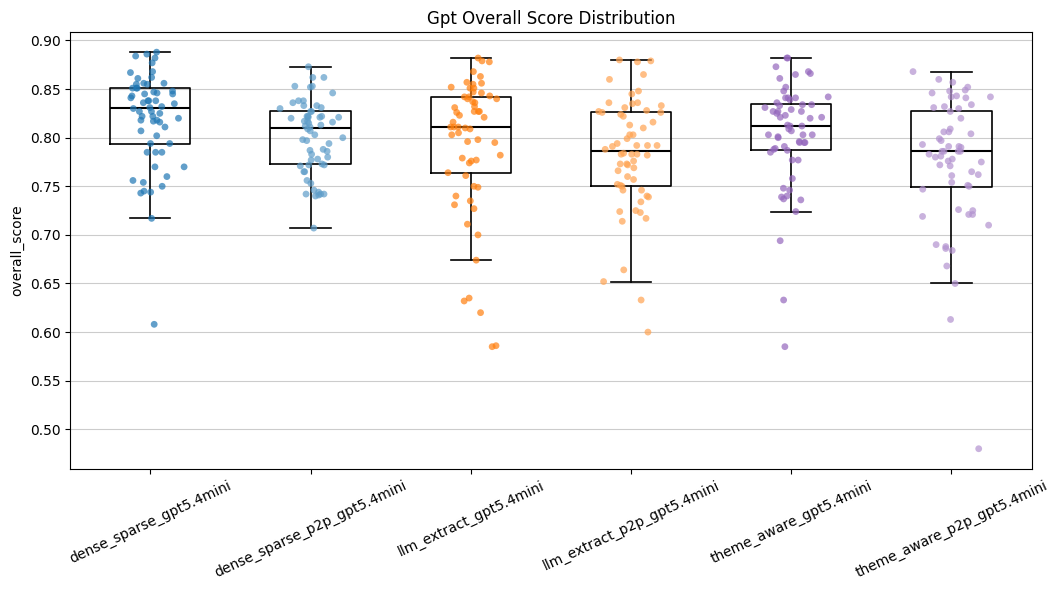

In [84]:
gpt_file_scores = plot_all_files_overall_scores_models(model="gpt")

## Question Visualization

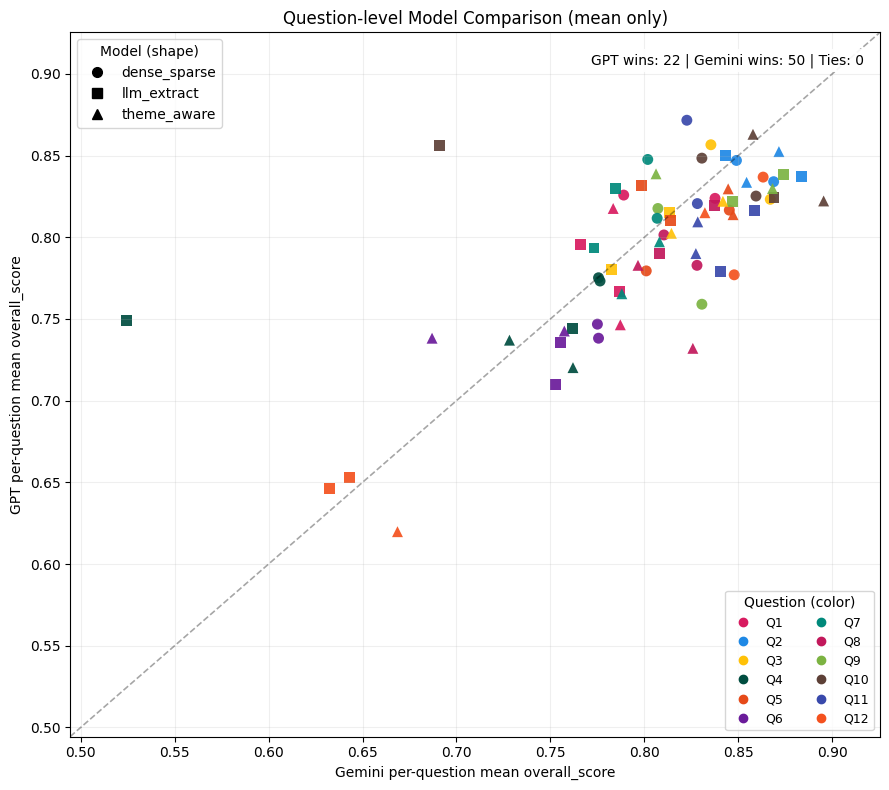

[dense_sparse] Q01: gemini=0.789, gpt=0.826, delta=+0.037 -> gpt
[dense_sparse] Q02: gemini=0.849, gpt=0.847, delta=-0.002 -> gemini
[dense_sparse] Q03: gemini=0.835, gpt=0.857, delta=+0.021 -> gpt
[dense_sparse] Q04: gemini=0.776, gpt=0.775, delta=-0.000 -> gemini
[dense_sparse] Q05: gemini=0.801, gpt=0.779, delta=-0.022 -> gemini
[dense_sparse] Q06: gemini=0.776, gpt=0.738, delta=-0.037 -> gemini
[dense_sparse] Q07: gemini=0.802, gpt=0.848, delta=+0.046 -> gpt
[dense_sparse] Q08: gemini=0.828, gpt=0.783, delta=-0.045 -> gemini
[dense_sparse] Q09: gemini=0.807, gpt=0.818, delta=+0.010 -> gpt
[dense_sparse] Q10: gemini=0.831, gpt=0.848, delta=+0.018 -> gpt
[dense_sparse] Q11: gemini=0.823, gpt=0.872, delta=+0.049 -> gpt
[dense_sparse] Q12: gemini=0.863, gpt=0.837, delta=-0.026 -> gemini
[dense_sparse_p2p] Q01: gemini=0.838, gpt=0.824, delta=-0.014 -> gemini
[dense_sparse_p2p] Q02: gemini=0.869, gpt=0.834, delta=-0.035 -> gemini
[dense_sparse_p2p] Q03: gemini=0.867, gpt=0.823, delta=-0.

In [85]:
# Gemini vs GPT per-question scatter comparison
question_compare_rows = compare_models_by_question_scatter(
    target_dir="data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern="*_llm_eval.json",
    runs_per_query=5,
    include_p2p=True,
)

Loaded 12 files from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results
Excluded test IDs: []
Queries per file: 12
Runs per query: 5
Complexity by query:
  Q1: high
  Q2: high
  Q3: medium
  Q4: medium
  Q5: medium
  Q6: medium
  Q7: medium
  Q8: low
  Q9: low
  Q10: low
  Q11: low
  Q12: low


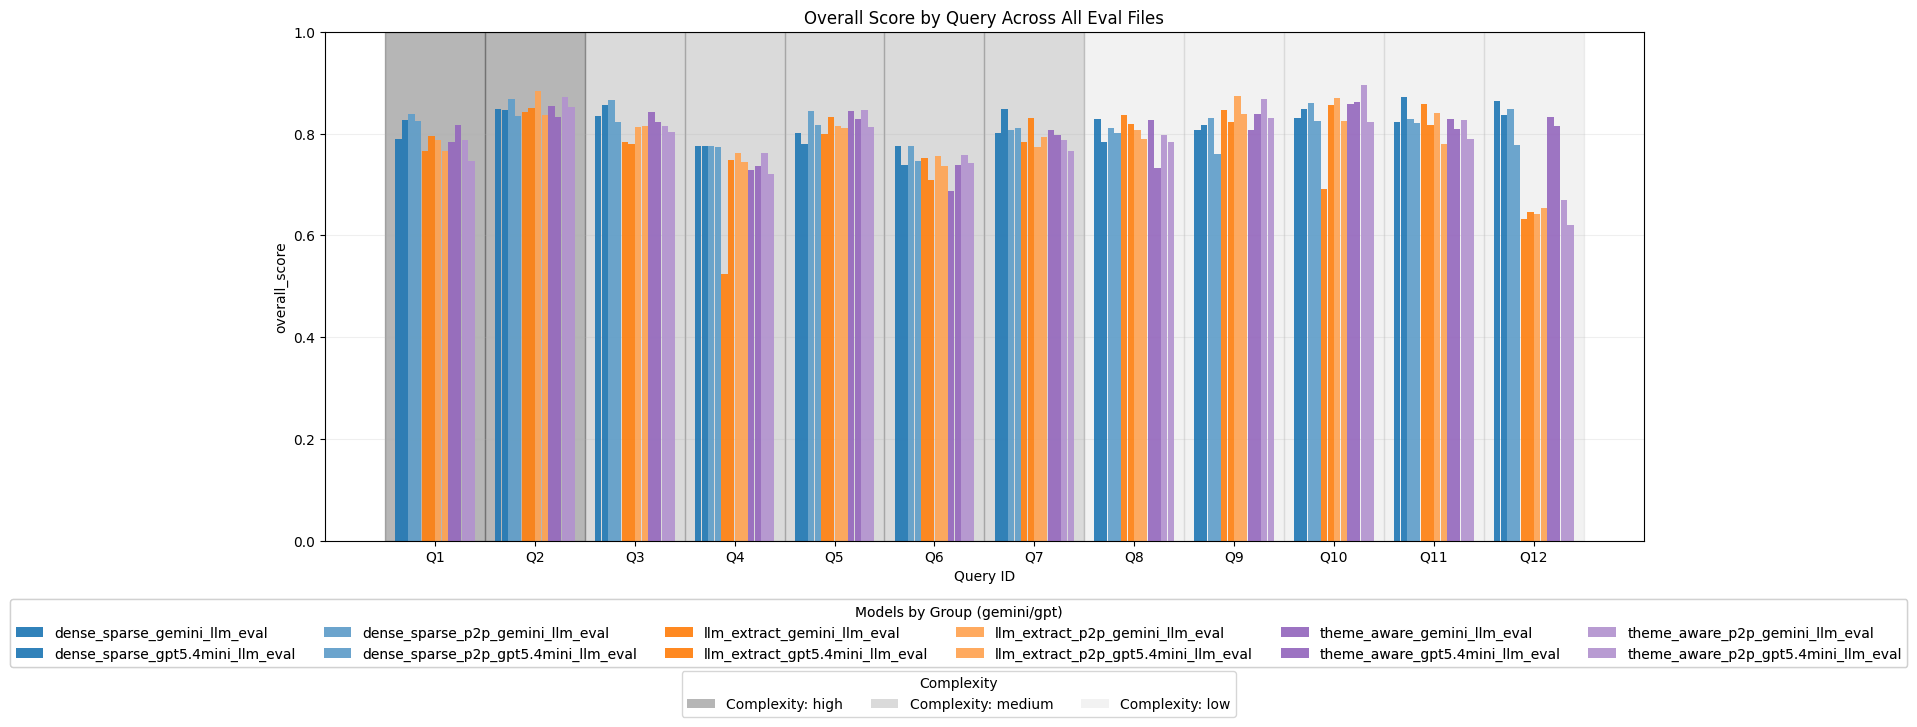

In [86]:
# Question-level grouped bar chart across all eval files
file_names, file_series = plot_overall_scores_by_query(
    target_dir="data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern="*_llm_eval.json",
    runs_per_query=5,
)

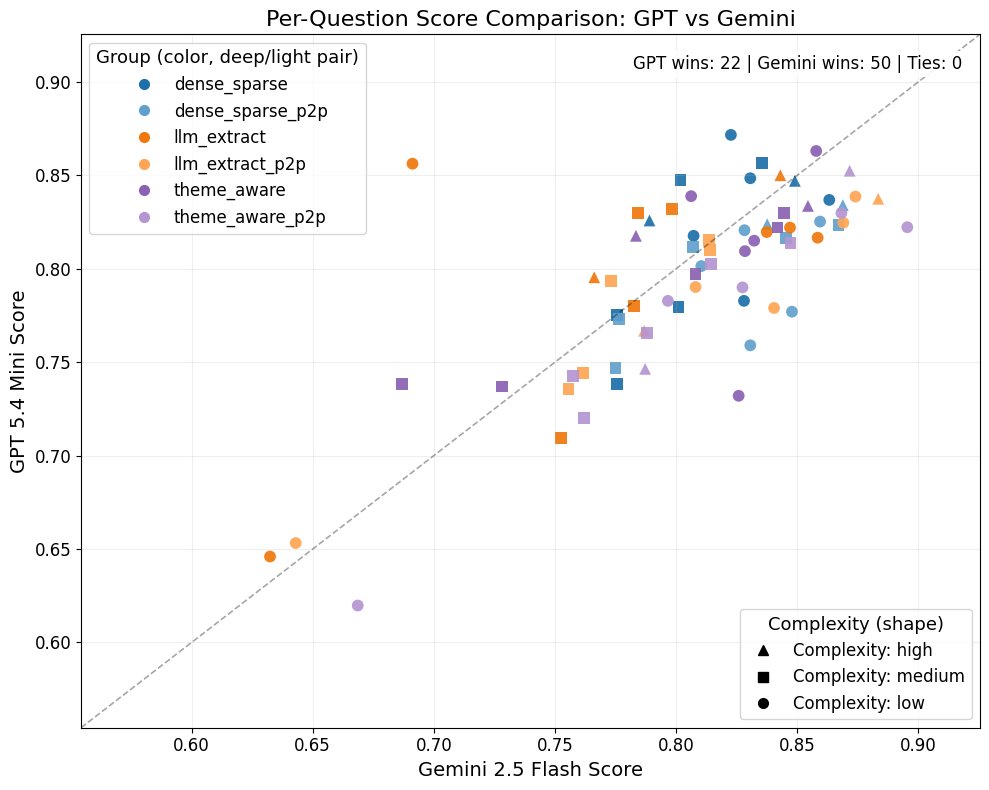

In [87]:
# GPT vs Gemini comparison (x=gemini, y=gpt)
# Color: method group with deep/light pair (base vs _p2p)
# Shape: query complexity

if "question_compare_rows" not in globals() or not question_compare_rows:
    question_compare_rows = compare_models_by_question_scatter(
        target_dir="data/llm_eval_results_compare/comparison_llm_eval_results",
        pattern="*_llm_eval.json",
        runs_per_query=5,
        include_p2p=True,
    )

base_group_colors = {
    "dense_sparse": "#1F77B4",
    "llm_extract": "#FF7F0E",
    "theme_aware": "#9467BD",
}
complexity_markers = {"high": "^", "medium": "s", "low": "o", "unknown": "X"}


def _point_color_for_group(group_name: str):
    base_name = _base_group_name(group_name)
    base_color = base_group_colors.get(base_name, "#4d4d4d")
    if group_name.endswith("_p2p"):
        return _blend_with_white(base_color, amount=0.30)
    return _blend_with_black(base_color, amount=0.06)


rows = question_compare_rows
all_means = [r["gemini_mean"] for r in rows] + [r["gpt_mean"] for r in rows]
lower = max(0.0, min(all_means) + 0.03)
upper = min(1.0, max(all_means) + 0.03)

fig, ax = plt.subplots(figsize=(10, 8))
# Font size settings
fontsize_labels = 14
fontsize_title = 16
fontsize_ticks = 12
fontsize_legend = 12

for r in rows:
    qid = int(r["query_id"])
    complexity = _complexity_for_query_id(qid)
    marker = complexity_markers.get(complexity, "X")
    color = _point_color_for_group(r["group"])
    ax.scatter(
        r["gemini_mean"],
        r["gpt_mean"],
        marker=marker,
        color=color,
        alpha=0.92,
        s=72,
        edgecolors="none",
    )

# y=x reference
ax.plot([lower, upper], [lower, upper], "k--", alpha=0.35, linewidth=1.2, label="y=x (equal)")

ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_xlabel("Gemini 2.5 Flash Score", fontsize=fontsize_labels)
ax.set_ylabel("GPT 5.4 Mini Score", fontsize=fontsize_labels)
ax.set_title("Per-Question Score Comparison: GPT vs Gemini", fontsize=fontsize_title)
ax.grid(True, alpha=0.2)
ax.tick_params(axis="both", labelsize=fontsize_ticks)

wins_gpt = sum(1 for r in rows if r["delta_gpt_minus_gemini"] > 1e-9)
wins_gemini = sum(1 for r in rows if r["delta_gpt_minus_gemini"] < -1e-9)
ties = len(rows) - wins_gpt - wins_gemini
ax.text(
    0.98,
    0.97,
    f"GPT wins: {wins_gpt} | Gemini wins: {wins_gemini} | Ties: {ties}",
    transform=ax.transAxes,
    va="top",
    ha="right",
    fontsize=12,
    bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "none", "pad": 3},
)

group_labels = []
for r in rows:
    if r["group"] not in group_labels:
        group_labels.append(r["group"])

group_handles = [
    plt.Line2D([0], [0], marker="o", color=_point_color_for_group(name), linestyle="", markersize=7, label=name)
    for name in group_labels
]
complexity_handles = [
    plt.Line2D([0], [0], marker=complexity_markers[level], color="black", linestyle="", markersize=7, label=f"Complexity: {level}")
    for level in ["high", "medium", "low"]
]

legend1 = ax.legend(
    handles=group_handles,
    loc="upper left",
    title="Group (color, deep/light pair)",
    fontsize=fontsize_legend,
    title_fontsize=fontsize_legend + 1,
)
ax.add_artist(legend1)
ax.legend(
    handles=complexity_handles,
    loc="lower right",
    title="Complexity (shape)",
    fontsize=fontsize_legend,
    title_fontsize=fontsize_legend + 1,
)

plt.tight_layout()
plt.show()


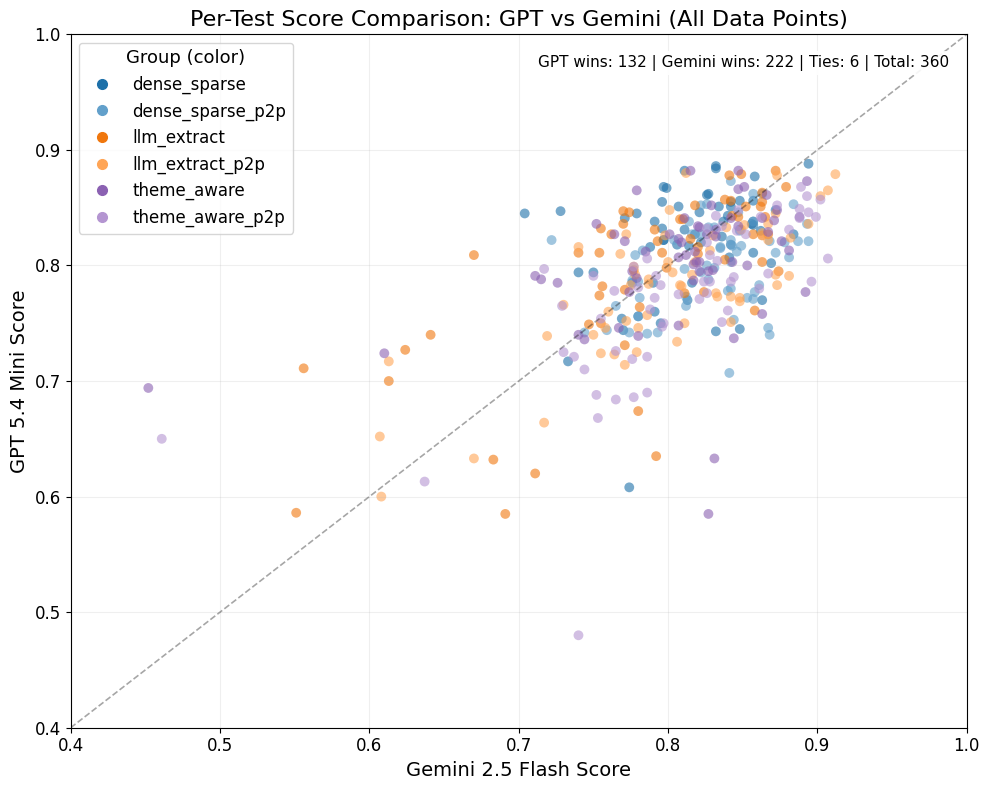

In [88]:
# Per-Question Score Comparison (All Data Points - No Mean Aggregation)
# Color: method group with deep/light pair (base vs _p2p)

resolved_dir = _resolve_eval_dir("data/llm_eval_results_compare/comparison_llm_eval_results")
files = sorted(
    list(resolved_dir.glob("*_llm_eval.json")),
    key=lambda p: (*_group_model_sort_key(p.stem), p.stem),
)

paired_models = {}
for file_path in files:
    group_name, model_name = _group_model_sort_key(file_path.stem)
    model_name = model_name.lower()
    if model_name == "gpt5.4mini":
        model_name = "gpt"
    if model_name not in {"gemini", "gpt"}:
        continue
    paired_models.setdefault(group_name, {})[model_name] = file_path

paired_groups = {
    group: model_map
    for group, model_map in paired_models.items()
    if "gemini" in model_map and "gpt" in model_map
}

all_points = []
for group_name, model_map in paired_groups.items():
    model_scores = {}
    model_test_ids = {}

    for model_name, file_path in model_map.items():
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        filtered_results = _filter_results_by_test_id(data.get("results", {}))
        sorted_keys = sorted(
            filtered_results.keys(),
            key=lambda x: int(str(x).split("_")[-1]),
        )

        scores = []
        test_ids = []
        for test_id in sorted_keys:
            score = filtered_results[test_id].get("overall_score", np.nan)
            if not np.isnan(score):
                scores.append(float(score))
                test_ids.append(test_id)

        model_scores[model_name] = scores
        model_test_ids[model_name] = test_ids

    if "gemini" not in model_scores or "gpt" not in model_scores:
        continue

    min_len = min(len(model_scores["gemini"]), len(model_scores["gpt"]))
    if min_len == 0:
        continue

    gem_scores = model_scores["gemini"][:min_len]
    gpt_scores = model_scores["gpt"][:min_len]
    test_ids_gemini = model_test_ids["gemini"][:min_len]

    for idx in range(min_len):
        query_id_str = str(test_ids_gemini[idx]).split("_")[-1]
        query_id = int(query_id_str) if query_id_str.isdigit() else 1
        all_points.append({
            "group": group_name,
            "query_id": query_id,
            "gemini_score": gem_scores[idx],
            "gpt_score": gpt_scores[idx],
            "test_id": test_ids_gemini[idx],
        })

fig, ax = plt.subplots(figsize=(10, 8))
fontsize_labels = 14
fontsize_title = 16
fontsize_ticks = 12
fontsize_legend = 12

for p in all_points:
    color = _point_color_for_group(p["group"])
    ax.scatter(
        p["gemini_score"],
        p["gpt_score"],
        marker="o",
        color=color,
        alpha=0.6,
        s=50,
        edgecolors="none",
    )

ax.plot([0.4, 1.0], [0.4, 1.0], "k--", alpha=0.35, linewidth=1.2, label="y=x (equal)")

ax.set_xlim(0.4, 1.0)
ax.set_ylim(0.4, 1.0)
ax.set_xlabel("Gemini 2.5 Flash Score", fontsize=fontsize_labels)
ax.set_ylabel("GPT 5.4 Mini Score", fontsize=fontsize_labels)
ax.set_title("Per-Test Score Comparison: GPT vs Gemini (All Data Points)", fontsize=fontsize_title)
ax.grid(True, alpha=0.2)
ax.tick_params(axis="both", labelsize=fontsize_ticks)

wins_gpt = sum(1 for p in all_points if p["gpt_score"] > p["gemini_score"] + 1e-9)
wins_gemini = sum(1 for p in all_points if p["gemini_score"] > p["gpt_score"] + 1e-9)
ties = len(all_points) - wins_gpt - wins_gemini
ax.text(
    0.98,
    0.97,
    f"GPT wins: {wins_gpt} | Gemini wins: {wins_gemini} | Ties: {ties} | Total: {len(all_points)}",
    transform=ax.transAxes,
    va="top",
    ha="right",
    fontsize=11,
    bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "none", "pad": 3},
)

group_labels = []
for p in all_points:
    if p["group"] not in group_labels:
        group_labels.append(p["group"])

group_handles = [
    plt.Line2D([0], [0], marker="o", color=_point_color_for_group(name), linestyle="", markersize=7, label=name)
    for name in group_labels
]

ax.legend(
    handles=group_handles,
    loc="upper left",
    title="Group (color)",
    fontsize=fontsize_legend,
    title_fontsize=fontsize_legend + 1,
)

plt.tight_layout()
plt.show()

# Function to plot results for each model

# Convert to Readable (CSV)

## Score Only

In [89]:
import csv


def export_flat_scores(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted([p for p in resolved_dir.glob(pattern) if "p2p" not in p.stem.lower()])

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    exported = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        filtered_results = _filter_results_by_test_id(data["results"])
        sorted_keys = sorted(filtered_results.keys(), key=lambda x: int(x.split("_")[-1]))

        rows = []
        for test_id in sorted_keys:
            record = filtered_results[test_id]
            policy = record.get("policy", {})
            provider = record.get("provider", {})
            query_alignment = record.get("query_alignment", {})
            compare_quality = record.get("compare_quality", {})

            row = {
                "test_id": test_id,
                "query": record.get("query", ""),
                "answer": record.get("answer", ""),
                "policy_faithfulness": policy.get("faithfulness", {}).get("score", ""),
                "policy_answer_relevance": policy.get("answer_relevance", {}).get("score", ""),
                "policy_correctness": policy.get("correctness", {}).get("score", ""),
                "provider_faithfulness": provider.get("faithfulness", {}).get("score", ""),
                "provider_answer_relevance": provider.get("answer_relevance", {}).get("score", ""),
                "provider_correctness": provider.get("correctness", {}).get("score", ""),
                "query_alignment": query_alignment.get("comparison_query_relevance", ""),
                "correctness": compare_quality.get("correctness", {}).get("score", ""),
                "accuracy_sim": compare_quality.get("accuracy_sim", {}).get("score", ""),
                "accuracy_diff": compare_quality.get("accuracy_diff", {}).get("score", ""),
                "completeness": compare_quality.get("completeness", {}).get("score", ""),
                "balance": compare_quality.get("balance", {}).get("score", ""),
                "comparison_overall_score": record.get("comparison_overall_score", ""),
                "overall_score": record.get("overall_score", ""),
            }
            rows.append(row)

        csv_path = file_path.with_name(file_path.stem + "_flat_scores.csv")
        fieldnames = list(rows[0].keys()) if rows else []

        with csv_path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(rows)

        exported[file_path.name] = csv_path
        print(f"Loaded from: {file_path}")
        print(f"Excluded test IDs: {sorted(EXCLUDED_TEST_IDS)}")
        print(f"Wrote CSV to: {csv_path}")
        print(f"Rows written: {len(rows)}")

    return exported


exported_csvs = export_flat_scores()


Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_gemini_llm_eval.json
Excluded test IDs: []
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_gemini_llm_eval_flat_scores.csv
Rows written: 60
Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_gpt5.4mini_llm_eval.json
Excluded test IDs: []
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_gpt5.4mini_llm_eval_flat_scores.csv
Rows written: 60
Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/llm_extract_gemini_llm_eval.json
Excluded test IDs: []
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eva

## Include Reasons

In [90]:
""""
def _flatten_record(value, parent_key="", sep="."):
    flat = {}

    if isinstance(value, dict):
        for k, v in value.items():
            new_key = f"{parent_key}{sep}{k}" if parent_key else str(k)
            flat.update(_flatten_record(v, new_key, sep=sep))
    elif isinstance(value, list):
        # Keep lists as JSON strings so variable-length arrays stay in one column.
        flat[parent_key] = json.dumps(value, ensure_ascii=False)
    else:
        flat[parent_key] = value

    return flat


def export_all_query_fields_to_csv(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted([p for p in resolved_dir.glob(pattern) if "p2p" not in p.stem.lower()])

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    exported = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        results = _filter_results_by_test_id(data.get("results", {}))
        # Keep JSON insertion order; do not sort test ids.
        key_order = list(results.keys())

        rows = []
        ordered_columns = ["test_id"]

        for test_id in key_order:
            record = results.get(test_id, {})
            flat_record = _flatten_record(record)
            row = {"test_id": test_id, **flat_record}
            rows.append(row)

            for col in row.keys():
                if col not in ordered_columns:
                    ordered_columns.append(col)

        fieldnames = ordered_columns
        csv_path = file_path.with_name(file_path.stem + "_all_fields.csv")

        with csv_path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
            writer.writeheader()
            for row in rows:
                writer.writerow({k: row.get(k, "") for k in fieldnames})

        exported[file_path.name] = csv_path
        print(f"Loaded from: {file_path}")
        print(f"Excluded test IDs: {sorted(EXCLUDED_TEST_IDS)}")
        print(f"Wrote CSV to: {csv_path}")
        print(f"Rows written: {len(rows)}")
        print(f"Columns written: {len(fieldnames)}")

    return exported


all_fields_csvs = export_all_query_fields_to_csv()
all_fields_csvs
"""

'"\ndef _flatten_record(value, parent_key="", sep="."):\n    flat = {}\n\n    if isinstance(value, dict):\n        for k, v in value.items():\n            new_key = f"{parent_key}{sep}{k}" if parent_key else str(k)\n            flat.update(_flatten_record(v, new_key, sep=sep))\n    elif isinstance(value, list):\n        # Keep lists as JSON strings so variable-length arrays stay in one column.\n        flat[parent_key] = json.dumps(value, ensure_ascii=False)\n    else:\n        flat[parent_key] = value\n\n    return flat\n\n\ndef export_all_query_fields_to_csv(\n    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",\n    pattern: str = "*_llm_eval.json",\n):\n    resolved_dir = _resolve_eval_dir(target_dir)\n    files = sorted([p for p in resolved_dir.glob(pattern) if "p2p" not in p.stem.lower()])\n\n    if not files:\n        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")\n\n    exported = {}\n    for file_path in fil